In [6]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [7]:
df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

In [8]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [12]:
df.isnull().sum()

transaction_id             0
user_id                    0
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64

In [11]:
df['addiction_level'].fillna(df['addiction_level'].mode()[0],inplace = True)

In [13]:
df.duplicated().sum()

np.int64(0)

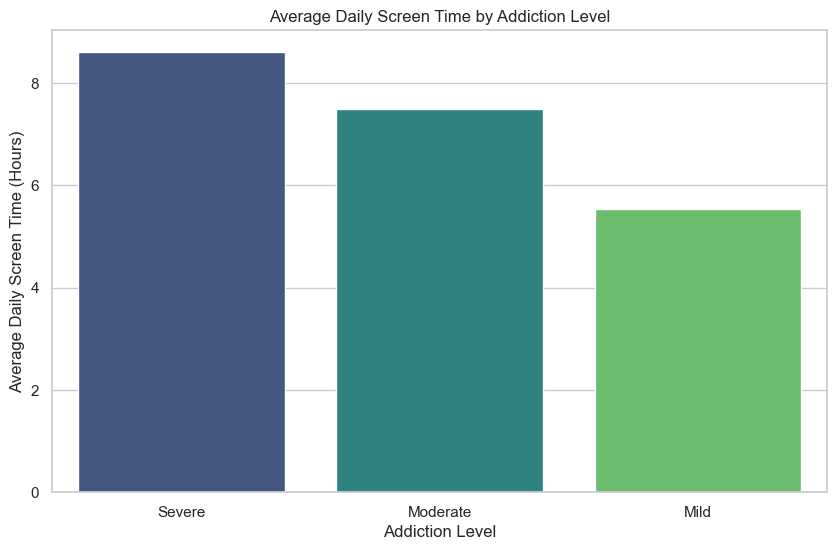

In [14]:
plt.figure(figsize=(10, 6))
grouped = df.groupby('addiction_level')['daily_screen_time_hours'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='addiction_level', y='daily_screen_time_hours', data=grouped, hue='addiction_level', palette='viridis', legend=False)
plt.title('Average Daily Screen Time by Addiction Level')
plt.xlabel('Addiction Level')
plt.ylabel('Average Daily Screen Time (Hours)')
plt.savefig('bar_plot_1.png')
plt.show()

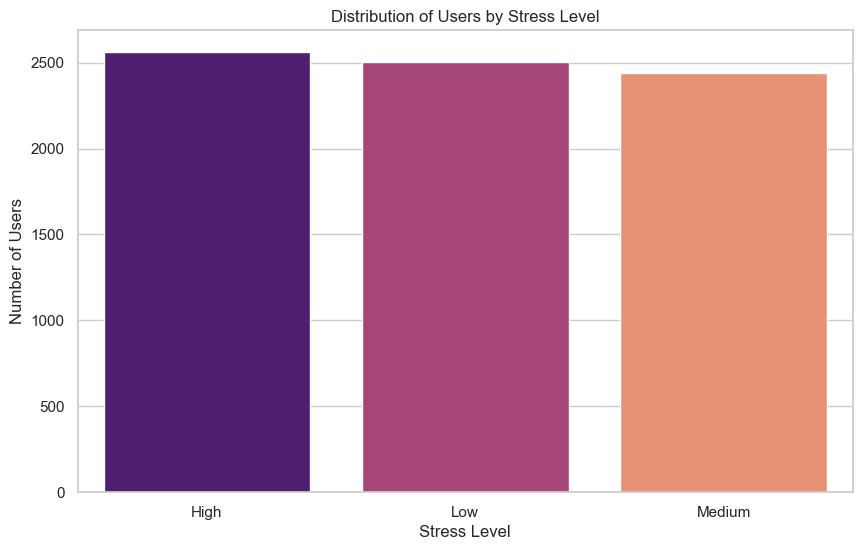

In [15]:
plt.figure(figsize=(10, 6))
stress_counts = df['stress_level'].value_counts().reset_index()
sns.barplot(x='stress_level', y='count', data=stress_counts, hue='stress_level', palette='magma', legend=False)
plt.title('Distribution of Users by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Number of Users')
plt.savefig('bar_plot_2.png')
plt.show()

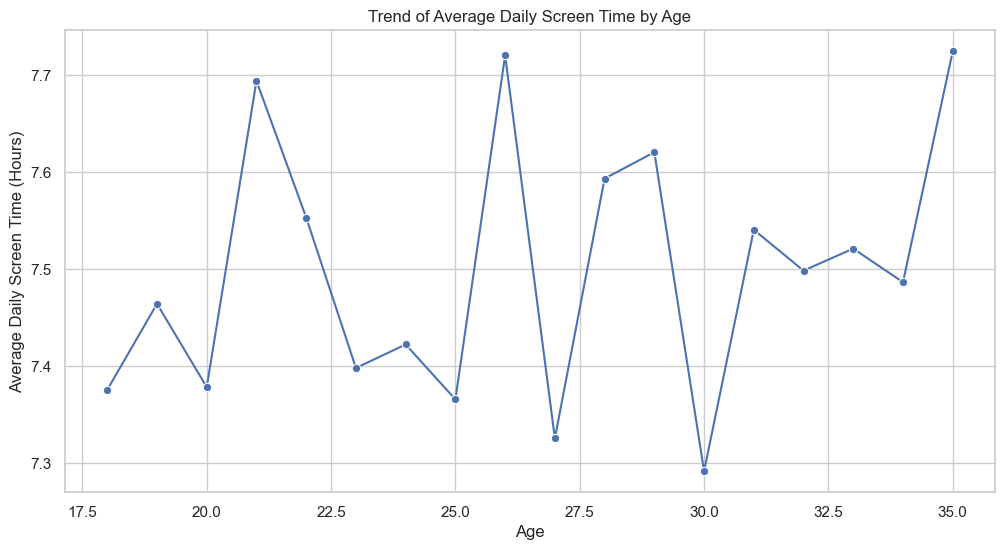

In [16]:
plt.figure(figsize=(12, 6))
age_screen_time = df.groupby('age')['daily_screen_time_hours'].mean().reset_index()
sns.lineplot(x='age', y='daily_screen_time_hours', data=age_screen_time, marker='o', color='b')
plt.title('Trend of Average Daily Screen Time by Age')
plt.xlabel('Age')
plt.ylabel('Average Daily Screen Time (Hours)')
plt.savefig('line_plot.png')
plt.show()

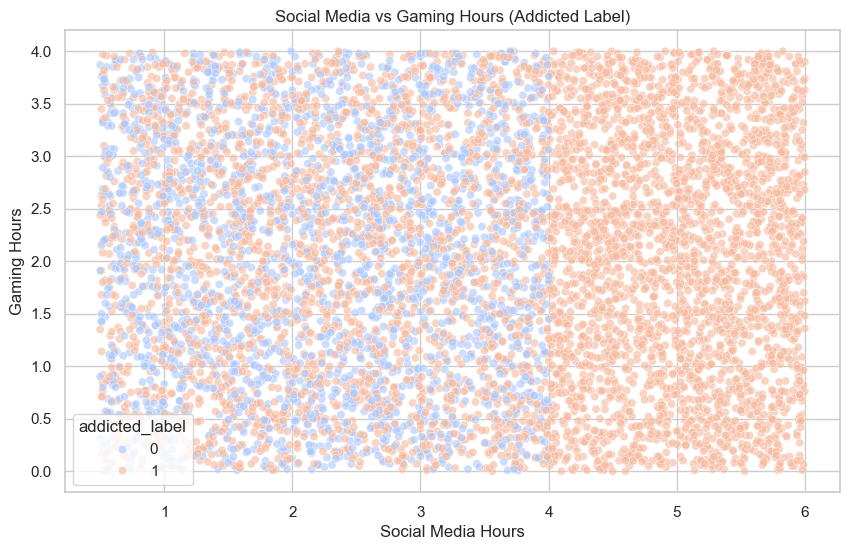

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='social_media_hours', y='gaming_hours', hue='addicted_label', data=df, alpha=0.6, palette='coolwarm')
plt.title('Social Media vs Gaming Hours (Addicted Label)')
plt.xlabel('Social Media Hours')
plt.ylabel('Gaming Hours')
plt.savefig('scatter_plot.png')
plt.show()

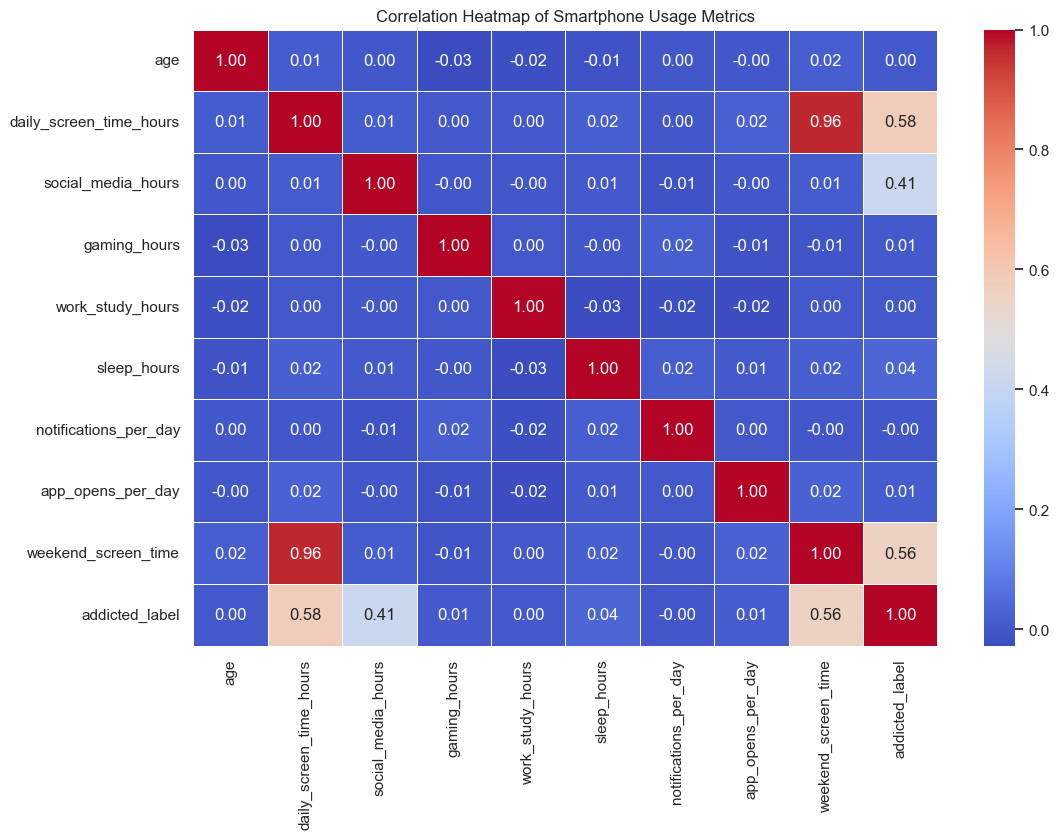

In [18]:
plt.figure(figsize=(12, 8))
numeric_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 
                'work_study_hours', 'sleep_hours', 'notifications_per_day', 
                'app_opens_per_day', 'weekend_screen_time', 'addicted_label']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Smartphone Usage Metrics')
plt.savefig('heatmap.png')
plt.show()